<a href="https://colab.research.google.com/github/A-Scode/ML-learning-notebooks/blob/main/face_recognition_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a) Face Recognition using CNN

In [2]:
from sklearn.datasets import fetch_lfw_people

In [3]:
lfw = fetch_lfw_people(min_faces_per_person=30)
lfw

{'data': array([[0.39738563, 0.37908497, 0.3503268 , ..., 0.13071896, 0.09803922,
         0.02875817],
        [0.01437909, 0.02745098, 0.05490196, ..., 0.2       , 0.20392157,
         0.21176471],
        [0.14248367, 0.20130719, 0.23267974, ..., 0.6248366 , 0.6235294 ,
         0.6248366 ],
        ...,
        [0.36993465, 0.34771243, 0.31764707, ..., 0.49803922, 0.4130719 ,
         0.36601308],
        [0.06143791, 0.04836601, 0.10849673, ..., 0.26143792, 0.24313726,
         0.23660131],
        [0.36732027, 0.34248367, 0.35555556, ..., 0.96732026, 0.9633987 ,
         0.6745098 ]], dtype=float32),
 'images': array([[[0.39738563, 0.37908497, 0.3503268 , ..., 0.24836601,
          0.18039216, 0.26666668],
         [0.34248367, 0.37777779, 0.36993465, ..., 0.28496733,
          0.18692811, 0.21437909],
         [0.33594772, 0.36078432, 0.35555556, ..., 0.3620915 ,
          0.29281047, 0.27058825],
         ...,
         [0.34771243, 0.36993465, 0.36078432, ..., 0.1124183 ,
     

In [4]:
y=lfw['target']
x=lfw['images']
x,y

(array([[[0.39738563, 0.37908497, 0.3503268 , ..., 0.24836601,
          0.18039216, 0.26666668],
         [0.34248367, 0.37777779, 0.36993465, ..., 0.28496733,
          0.18692811, 0.21437909],
         [0.33594772, 0.36078432, 0.35555556, ..., 0.3620915 ,
          0.29281047, 0.27058825],
         ...,
         [0.34771243, 0.36993465, 0.36078432, ..., 0.1124183 ,
          0.10718954, 0.0496732 ],
         [0.275817  , 0.33333334, 0.35555556, ..., 0.13071896,
          0.10980392, 0.03529412],
         [0.19607843, 0.23660131, 0.31895426, ..., 0.13071896,
          0.09803922, 0.02875817]],
 
        [[0.01437909, 0.02745098, 0.05490196, ..., 0.16470589,
          0.15816994, 0.14640523],
         [0.02614379, 0.04183007, 0.04052288, ..., 0.18431373,
          0.16470589, 0.15294118],
         [0.03529412, 0.08235294, 0.08627451, ..., 0.18954249,
          0.15816994, 0.13725491],
         ...,
         [0.16993465, 0.18300654, 0.19346406, ..., 0.18692811,
          0.19084968, 0.

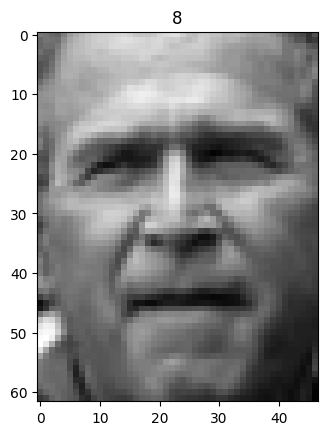

In [5]:
import matplotlib.pyplot as plt

plt.imshow(x[0] , cmap="gray")
plt.title(y[0])
plt.show()

In [6]:
x[0].shape , print(y[0])

8


((62, 47), None)

In [7]:
x.shape , y.shape

((2370, 62, 47), (2370,))

In [8]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
import torch
from torch.utils.data import Dataset

class FaceDataset(Dataset):
  def __init__(self , images , labels):
    self.images= torch.tensor(images).unsqueeze(1).float() / 255.0
    self.labels = torch.tensor(labels)

  def __len__(self):
    return (len(self.images))

  def __getitem__(self, index):
    return self.images[index] , self.labels[index]




In [10]:
import torch.nn as nn
import torch.nn.functional as F

class FaceCNN(nn.Module):

  def __init__(self, num_classess) -> None:
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=1,out_channels=32, kernel_size=3)
    self.bn1 = nn.BatchNorm2d(32)
    self.conv2 = nn.Conv2d(32,64,3)
    self.bn2 = nn.BatchNorm2d(64)
    self.conv3 = nn.Conv2d(64,256,3)
    self.bn3 = nn.BatchNorm2d(256)
    self.conv4 = nn.Conv2d(256,128,3)
    self.bn4 = nn.BatchNorm2d(128)

    self.pool = nn.MaxPool2d(2,2)
    self.dropout = nn.Dropout(p=0.1)

    self.fc1 = nn.Linear(256, 2408)
    self.fc2 = nn.Linear(2408, 1024)
    self.fc3 = nn.Linear(1024, 512)
    self.fc4 = nn.Linear(512, 256)
    self.embedding = nn.Linear(256 , 128)
    self.classifier = nn.Linear(128 , num_classess)


  def forward(self, x ):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))
    x = self.pool(F.relu(self.bn2(self.conv2(x))))
    x = self.pool(F.relu(self.bn3(self.conv3(x))))
    x = self.pool(F.relu(self.bn4(self.conv4(x))))
    x = torch.flatten(x,1)


    # this layer will not be registered in model.parameters therefore no weight update
    # if self.fc1 is None:
    #   self.fc1 = nn.Linear(x.shape[1] , 256).to(x.device)

    x  = F.relu(self.fc1(x))
    x  = F.relu(self.fc2(x))
    x  = F.relu(self.fc3(x))
    x  = F.relu(self.fc4(x))

    emb = self.embedding(x)

    out  = self.classifier(emb)

    return out , emb

In [11]:
from sklearn.model_selection import train_test_split

x_train ,x_test , y_train, y_test = train_test_split( x , y  , test_size=0.2 , random_state=42)

x_train.shape ,x_test.shape , y_train.shape, y_test.shape

((1896, 62, 47), (474, 62, 47), (1896,), (474,))

In [12]:
train_dataset =FaceDataset(x_train , y_train)
test_dataset = FaceDataset(x_test , y_test)

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True , num_workers=4)
test_loader = DataLoader(test_dataset , batch_size=32  , shuffle=True , num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
num_classess = len(lfw.target_names)
model =  FaceCNN(num_classess).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters() , lr=0.0005)

for epoch in  range(30):
  for images , labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    model.train()
    optimizer.zero_grad()

    out ,emb = model(images)

    loss  = criterion(out , labels)
    print(f"Epoch {epoch} : loss {loss}")
    loss.backward()
    optimizer.step()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 0 : loss 3.541494131088257
Epoch 0 : loss 3.5034596920013428
Epoch 0 : loss 3.3592164516448975
Epoch 0 : loss 3.252126693725586
Epoch 0 : loss 3.0690932273864746
Epoch 0 : loss 3.2102420330047607
Epoch 0 : loss 2.7527997493743896
Epoch 0 : loss 3.4097683429718018
Epoch 0 : loss 3.1611223220825195
Epoch 0 : loss 3.0744924545288086
Epoch 0 : loss 3.0858006477355957
Epoch 0 : loss 3.192894458770752
Epoch 0 : loss 3.20066499710083
Epoch 0 : loss 3.123385190963745
Epoch 0 : loss 3.1191935539245605
Epoch 0 : loss 3.402092456817627
Epoch 0 : loss 3.1497750282287598
Epoch 0 : loss 2.9533896446228027
Epoch 0 : loss 2.9126477241516113
Epoch 0 : loss 3.4216723442077637
Epoch 0 : loss 3.350914478302002
Epoch 0 : loss 3.009176731109619
Epoch 0 : loss 3.0896871089935303
Epoch 0 : loss 3.057439088821411
Epoch 0 : loss 3.1555166244506836
Epoch 0 : loss 3.093261480331421
Epoch 0 : loss 3.1647815704345703
Epoch 0 : loss 3.188659906387329
Epoch 0 : loss 3.140281915664673
Epoch 0 : loss 3.2204055786

In [15]:
model.eval()

FaceCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=256, out_features=2408, bias=True)
  (fc2): Linear(in_features=2408, out_features=1024, bias=True)
  (fc3): Linear(in_features=1024, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=256, bias=True)
  (embe

In [16]:
correct = 0
total  = 0

with torch.no_grad():

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    out , _ = model(images)
    _ , pred = torch.max(out , 1)
    total +=  labels.size(0)
    correct += (pred == labels).sum().item()
  acc = 100*correct/total

  print("test Accuracy : " , acc)



test Accuracy :  74.68354430379746


In [17]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode


def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))

  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

In [18]:

photo1 = take_photo("photo1.jpg")
print("Saved to", photo1)

photo2 = take_photo("photo2.jpg")

<IPython.core.display.Javascript object>

Saved to photo1.jpg


<IPython.core.display.Javascript object>

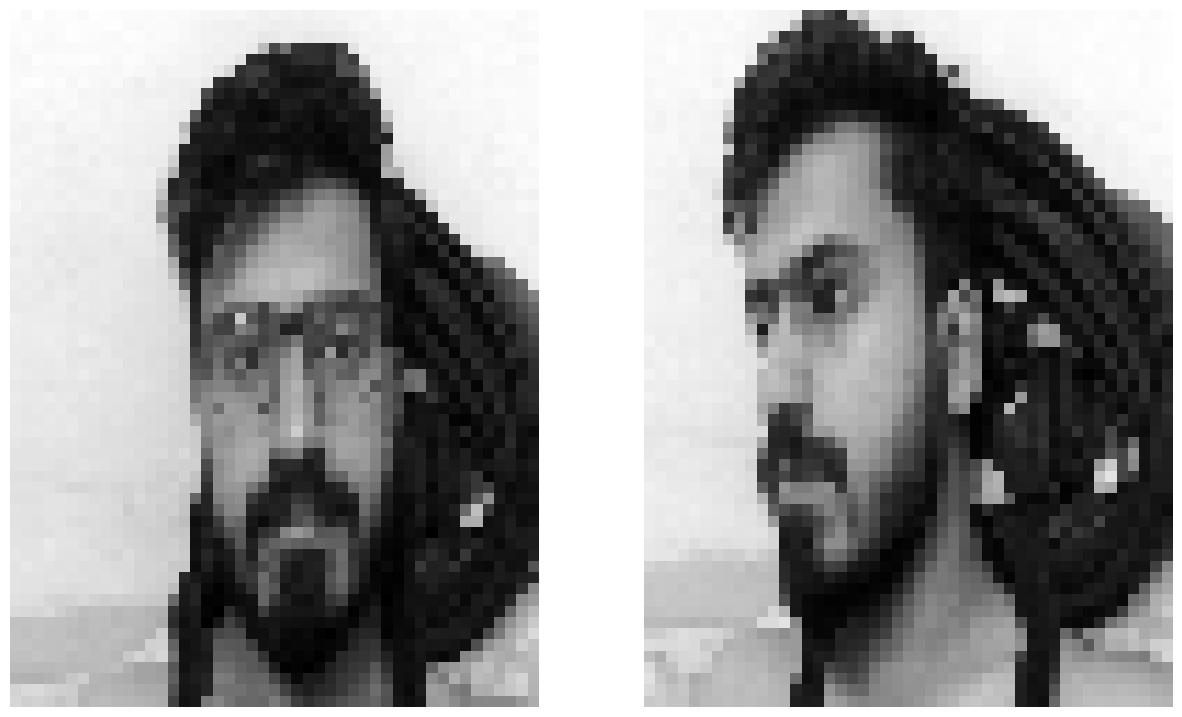

In [19]:
im1 = cv2.imread(photo1)
im2 = cv2.imread(photo2)

im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# resizing
im1 = cv2.resize(im1 , (47,62))
im2 = cv2.resize(im2 , (47,62))

plt.figure(figsize=(15,15))

ax1 = plt.subplot(121)
ax1.axis("off")
ax1.imshow(im1 , cmap="gray")

ax2 = plt.subplot(122)
ax2.axis("off")
ax2.imshow(im2 , cmap="gray")

plt.show()

# plt.imshow(im1 , cmap="gray")
# plt.title("photo 1")
# plt.axis('off')


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Shape is (62, 47, 3) -> (H, W, C)
t1 = torch.from_numpy(im1).float() / 255
t2 = torch.from_numpy(im2).float() / 255

t1 = t1.unsqueeze(0).unsqueeze(0).to(device)
t2 = t2.unsqueeze(0).unsqueeze(0).to(device)

print(t1.shape)

model.eval()

_ ,emb_1 = model(t1)
_ ,emb_2 = model(t2)


print("emb1 : " , emb_1)
print("emb2 : " , emb_2)

emb_1 = emb_1.reshape(1,-1)
emb_2 = emb_2.reshape(1,-1)

cs = cosine_similarity(emb_1.to("cpu").detach().numpy() , emb_2.to("cpu").detach().numpy())


print("cosine similarity :" , cs[0][0])

torch.Size([1, 1, 62, 47])
emb1 :  tensor([[  79.2155,   64.3287,  -37.9719,   97.7604, -190.0295,  -68.9474,
         -105.1445,    0.3824, -166.8285,  114.0348,  -28.5588,   84.4522,
          236.7267,  -53.4107,  169.2226,  -16.6842, -359.2723,  284.7013,
           13.0902,  -91.7895,   21.3973,  127.2719, -111.1483,   -6.4608,
          229.8272, -202.1461, -204.6685,   -0.4656,  -16.3612,  -15.7135,
          -74.0804,  130.7909,  106.4925, -128.7327,   83.0328,  -72.9668,
          101.0223, -100.3832,   35.2626,  -61.1974,  -13.5666, -149.9635,
          103.5412,   94.4545,   37.7976,  344.2105,   82.2462,  249.4981,
         -277.4813,  134.1865,  -54.2861, -175.5798, -193.3910,   -0.9472,
          152.7038,  192.0685,   37.3958,  160.9968,   77.6394, -266.4063,
          -86.6646, -190.6057,  134.2667,  166.4690,   96.9047, -114.6904,
          -22.9344,  148.8437,   -5.9086,  235.6220,  -31.5893,   42.0820,
           38.0845,  -19.5850,   51.7868,  230.8882,   23.7597,  

Save the model

In [21]:
torch.save(model.state_dict() , "/content/drive/MyDrive/Colab Notebooks/models/face-recognition-lfw-state-dict.pth")


#b) Model using Transfer learning

In [22]:
# model.train(mode=False)

In [26]:
class FaceCNN_Adapt(nn.Module):
  def __init__(self ) -> None:
    super().__init__()
    self.conv1 = model.conv1
    self.bn1 = model.bn1
    self.conv2 = model.conv2
    self.bn2 = model.bn2
    self.conv3 = model.conv3
    self.bn3 = model.bn3
    self.conv4 = model.conv4
    self.bn4 = model.bn4

    self.pool = model.pool
    self.dropout = model.dropout

    self.fc1 = model.fc1
    self.fc2 = model.fc2
    self.fc3 = model.fc3
    self.fc4 = model.fc4
    self.embedding = model.embedding

    for param in self.parameters():
      param.requires_grad = False

    self.add_fc1 = nn.Linear(128 , 256)
    self.add_fc2 = nn.Linear(256 , 512)
    self.classifier = nn.Linear(512 , num_classess)

  def forward(self , x ):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))
    x = self.pool(F.relu(self.bn2(self.conv2(x))))
    x = self.pool(F.relu(self.bn3(self.conv3(x))))
    x = self.pool(F.relu(self.bn4(self.conv4(x))))
    x = torch.flatten(x,1)
    x  = F.relu(self.fc1(x))
    x  = F.relu(self.fc2(x))
    x  = F.relu(self.fc3(x))
    x  = F.relu(self.fc4(x))

    emb = self.embedding(x)

    x =  F.relu(self.add_fc1(emb))
    x =  F.relu(self.add_fc2(x))
    classifier =  self.classifier(x)

    return classifier


In [32]:
model_adapted = FaceCNN_Adapt().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)

optimizer = torch.optim.Adam(model_adapted.parameters() , lr=0.0005)

for epoch in range(20):
  flag = True
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()

    class_ = model_adapted(images)

    loss = criterion(class_ , labels)
    loss.backward()
    optimizer.step()

    if flag :
      print(f"Epoch {epoch+1}: {loss}")
      flag = False

Epoch 1: 3.514150619506836
Epoch 2: 0.37062934041023254
Epoch 3: 0.11094518005847931
Epoch 4: 0.10137300193309784
Epoch 5: 0.10301865637302399
Epoch 6: 0.09688696265220642
Epoch 7: 0.09301376342773438
Epoch 8: 0.09487732499837875
Epoch 9: 0.09970680624246597
Epoch 10: 0.09438604861497879
Epoch 11: 0.09293898940086365
Epoch 12: 0.09713031351566315
Epoch 13: 0.09431999921798706
Epoch 14: 0.09215421974658966
Epoch 15: 0.09135308116674423
Epoch 16: 0.09175039827823639
Epoch 17: 0.09313192963600159
Epoch 18: 0.0921623632311821
Epoch 19: 0.0909280851483345
Epoch 20: 0.09066158533096313


In [36]:
correct = 0
total  = 0

with torch.no_grad():

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    class_ = model_adapted(images)
    _ , pred = torch.max(class_ , 1)
    total +=  labels.size(0)
    correct += (pred == labels).sum().item()
  acc = 100*correct/total

  print("test Accuracy : " , acc)



test Accuracy :  79.74683544303798
